<a href="https://colab.research.google.com/github/Faizan-Jamil91/NED-DS-Deep-learning-/blob/main/DS_GenAI_Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#!/bin/bash
!kaggle datasets download puneet6060/intel-image-classification

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:03<00:00, 69.0MB/s]
100% 346M/346M [00:03<00:00, 96.7MB/s]


In [2]:
import zipfile

# Path to the dataset
dataset_path = "/content/intel-image-classification.zip"

# Extract the dataset
with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
    zip_ref.extractall("/content/intel-image-classification")

print("Dataset unzipped successfully!")


Dataset unzipped successfully!


In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt



In [6]:
# Define paths to dataset
train_dir = "/content/intel-image-classification/seg_train/seg_train"
val_dir = "/content/intel-image-classification/seg_pred"
test_dir = "/content/intel-image-classification/seg_test/seg_test"



In [7]:
# Image data generators with augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(150, 150), batch_size=32, class_mode='sparse'
)
val_generator = val_test_datagen.flow_from_directory(
    val_dir, target_size=(150, 150), batch_size=32, class_mode='sparse'
)
test_generator = val_test_datagen.flow_from_directory(
    test_dir, target_size=(150, 150), batch_size=32, class_mode='sparse', shuffle=False
)



Found 14034 images belonging to 6 classes.
Found 7301 images belonging to 1 classes.
Found 3000 images belonging to 6 classes.


In [8]:
# CNN Model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dense(6, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# Train the model
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator
)



Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


439/439 ━━━━━━━━━━━━━━━━━━━━ 113s 245ms/step - accuracy: 0.4952 - loss: 1.2844 - val_accuracy: 0.1466 - val_loss: 4.2634
Epoch 2/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 108s 243ms/step - accuracy: 0.6608 - loss: 0.8817 - val_accuracy: 0.1955 - val_loss: 3.4173
Epoch 3/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 137s 232ms/step - accuracy: 0.7197 - loss: 0.7693 - val_accuracy: 0.1552 - val_loss: 4.0260
Epoch 4/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 108s 242ms/step - accuracy: 0.7322 - loss: 0.7250 - val_accuracy: 0.1478 - val_loss: 4.3376
Epoch 5/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 141s 241ms/step - accuracy: 0.7604 - loss: 0.6552 - val_accuracy: 0.2057 - val_loss: 4.0542
Epoch 6/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 105s 237ms/step - accuracy: 0.7657 - loss: 0.6280 - val_accuracy: 0.1638 - val_loss: 4.3356
Epoch 7/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 143s 239ms/step - accuracy: 0.7721 - loss: 0.6112 - val_accuracy: 0.1660 - val_loss: 4.9099
Epoch 8/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 140s 234ms/step - accuracy: 0.7971 - loss: 0.55

In [10]:
# Evaluate the model
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.2f}")



94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.8470 - loss: 0.4038
Test Accuracy: 0.87


In [11]:
# Confusion matrix and classification report
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np



In [12]:
# Predict test data
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys()))



94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step
Classification Report:
              precision    recall  f1-score   support

   buildings       0.90      0.79      0.84       437
      forest       0.97      0.97      0.97       474
     glacier       0.82      0.85      0.83       553
    mountain       0.84      0.79      0.81       525
         sea       0.88      0.87      0.87       510
      street       0.82      0.94      0.87       501

    accuracy                           0.87      3000
   macro avg       0.87      0.87      0.87      3000
weighted avg       0.87      0.87      0.87      3000



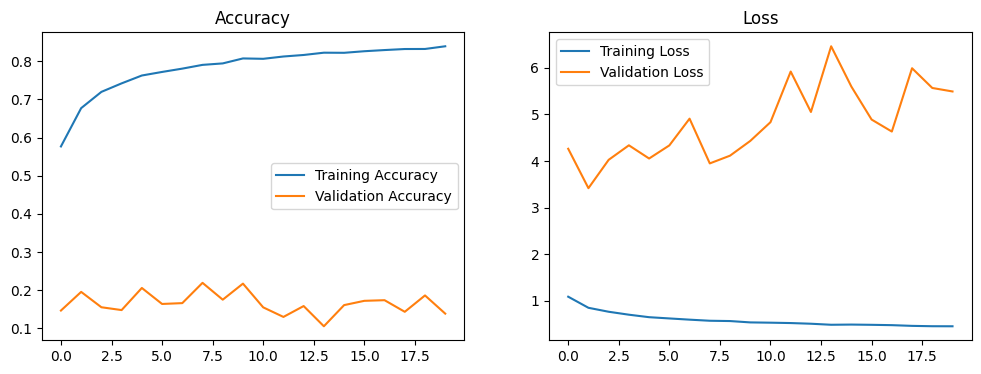

In [13]:
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()
